# High-Accuracy LSTM for Fault Prediction (c1355)


In [ ]:
import sys, platform, subprocess, time

try:
    import psutil
    ram_gb = psutil.virtual_memory().total / 1e9
    cpu_logical = psutil.cpu_count(logical=True)
except Exception:
    ram_gb = None; cpu_logical = None

print("=== Environment ===")
print("Python:", sys.version.replace(chr(10), ' '))
print("Platform:", platform.platform())
print("CPU logical cores:", cpu_logical)
print("RAM (GB):", None if ram_gb is None else round(ram_gb, 2))

try:
    import torch
    print(chr(10) + "=== PyTorch ===")
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory/1e9, 2))
    else:
        print(chr(10) + "WARNING: no GPU. Runtime > Change runtime type > T4 GPU.")
except Exception as e:
    print(chr(10) + "PyTorch not available:", e)

print(chr(10) + "=== nvidia-smi ===")
try:
    print(subprocess.check_output(["nvidia-smi"], text=True).splitlines()[0])
except Exception as e:
    print("nvidia-smi not available:", e)


=== Environment ===
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CPU logical cores: 2
RAM (GB): 13.61

=== PyTorch ===
torch: 2.11.0+cu128
cuda available: True
GPU: Tesla T4
VRAM (GB): 15.64

=== nvidia-smi ===
Wed Jun 17 01:02:06 2026       


In [ ]:
# ===== Timing + Peak RAM/VRAM helper (identical to your ANN/LSTM notebooks) =====
import os, time, threading, subprocess

try:
    import psutil
    _ps_proc = psutil.Process(os.getpid())
except Exception:
    psutil = None; _ps_proc = None

def rss_mb():
    if _ps_proc is None: return None
    return _ps_proc.memory_info().rss / (1024**2)

def gpu_vram_mb():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"], text=True)
        return float(out.strip().splitlines()[0])
    except Exception:
        return None

class PeakMonitor:
    def __init__(self, interval_sec=0.5):
        self.interval = interval_sec; self._stop = False
        self.peak_rss = 0.0; self.peak_vram = 0.0; self._thread = None
    def _run(self):
        while not self._stop:
            r = rss_mb()
            if r is not None: self.peak_rss = max(self.peak_rss, float(r))
            v = gpu_vram_mb()
            if v is not None: self.peak_vram = max(self.peak_vram, float(v))
            time.sleep(self.interval)
    def start(self):
        self._stop = False; self.peak_rss = 0.0; self.peak_vram = 0.0
        self._thread = threading.Thread(target=self._run, daemon=True); self._thread.start()
    def stop(self):
        self._stop = True
        if self._thread is not None: self._thread.join(timeout=2)
        return self.peak_rss, self.peak_vram


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Same path convention as your notebooks.
test_path = '/content/drive/My Drive/circuits/c1355.test'

MAX_EXPAND    = 3          # don't-care expansion, matches your baseline
BITS_PER_STEP = 1          # bits packed per LSTM timestep (1 = your original bit-per-step)
MAX_SAMPLES   = None   # stratified cap; set None to use ALL rows (slow on big files)
HIDDEN_SIZE   = 192        # LSTM hidden units per direction
EPOCHS        = 60
LR            = 0.0015
BATCH_SIZE    = 256        # larger than your 64 -> better GPU throughput on big data


In [ ]:
import itertools, random
from collections import defaultdict
import numpy as np, torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn, torch.optim as optim

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def expand_dont_care_limited(pattern, max_expand=15):
    x_indices = [i for i, c in enumerate(pattern) if c == 'x']
    if len(x_indices) <= max_expand:
        chars = [(c if c in '01' else ['0', '1']) for c in pattern]
        chars = [(c if isinstance(c, list) else [c]) for c in chars]
        return [''.join(bits) for bits in itertools.product(*chars)]
    else:
        fixed_pattern = list(pattern); patterns = []
        for bits in itertools.product('01', repeat=max_expand):
            temp = fixed_pattern.copy()
            for i, bit in zip(x_indices[:max_expand], bits): temp[i] = bit
            for i in x_indices[max_expand:]: temp[i] = random.choice('01')
            patterns.append(''.join(temp))
        return patterns

def parse_isc_file_limited(filepath, max_expand=3):
    # Identical logic to your baseline parser (dedup by combined pattern).
    combo_to_fault = {}; fault_to_idx = {}; fault_type_map = {}
    idx = 0; current_fault = None
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
            if not line or line.startswith("*"): continue
            if '/' in line:
                parts = line.split("/")
                fault = parts[0].strip().replace("->", "_") + "/" + parts[1].strip()
                if fault not in fault_to_idx:
                    fault_to_idx[fault] = idx
                    fault_type_map[idx] = "stuck-at-0" if parts[1].strip()=="0" else (
                        "stuck-at-1" if parts[1].strip()=="1" else "unknown")
                    idx += 1
                current_fault = fault
            elif ':' in line and current_fault:
                parts = line.split(":")[1].strip().split()
                input_pat = parts[0]; output_pat = parts[1] if len(parts) > 1 else ""
                for xi in expand_dont_care_limited(input_pat, max_expand):
                    for yo in expand_dont_care_limited(output_pat, max_expand):
                        combined = xi + yo
                        if combined not in combo_to_fault:
                            combo_to_fault[combined] = fault_to_idx[current_fault]
    return combo_to_fault, fault_to_idx, fault_type_map

def stratified_subsample(combo_to_fault, max_samples, seed=SEED):
    """Class-balanced cap so every fault keeps representation. Deterministic."""
    if not max_samples or len(combo_to_fault) <= max_samples:
        return dict(combo_to_fault)
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for c, l in combo_to_fault.items(): by_class[l].append((c, l))
    frac = max_samples / len(combo_to_fault)
    out = []
    for l, rows in by_class.items():
        rng.shuffle(rows)
        keep = max(1, int(round(len(rows) * frac)))
        out.extend(rows[:keep])
    rng.shuffle(out)
    return dict(out[:max_samples])


In [ ]:
class FaultDatasetMC(Dataset):
    """Bit string -> [seq_len, BITS_PER_STEP] float tensor + class label.
    BITS_PER_STEP=1 reproduces your original [seq_len, 1] representation.
    """
    def __init__(self, combo_to_fault, bits_per_step=1):
        self.k = bits_per_step
        combos = list(combo_to_fault.keys())
        labels = list(combo_to_fault.values())
        L = len(combos[0])
        Lpad = ((L + self.k - 1) // self.k) * self.k
        self.seq_len = Lpad // self.k
        # vectorized char-grid -> float matrix [N, Lpad]
        grid = np.frombuffer(''.join(combos).encode('ascii'), dtype=np.uint8).reshape(len(combos), L)
        X = (grid == ord('1')).astype(np.float32)
        if Lpad != L:
            X = np.pad(X, ((0, 0), (0, Lpad - L)))
        self.X = X
        self.y = np.asarray(labels, dtype=np.int64)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).view(self.seq_len, self.k)
        return x, torch.tensor(self.y[idx], dtype=torch.long)


In [ ]:
class FaultLSTMClassifier(nn.Module):
    """Your 2-layer LSTM, upgraded to bidirectional. Readout = concatenation
    of the final hidden state from both directions (last layer).
    """
    def __init__(self, input_size, hidden_size, num_classes,
                 num_layers=2, dropout=0.3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            dropout=dropout, batch_first=True, bidirectional=bidirectional)
        out_dim = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, num_classes)
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        if self.bidirectional:
            h = torch.cat([hn[-2], hn[-1]], dim=1)   # last layer, both directions
        else:
            h = hn[-1]
        return self.fc(h)


In [ ]:
# ===== Data + model setup (c1355 / LSTM) =====
setup_monitor = PeakMonitor(interval_sec=0.5)
t_setup0 = time.time(); setup_monitor.start()

combo_to_fault, fault_to_idx, fault_type_map = parse_isc_file_limited(test_path, max_expand=MAX_EXPAND)
print(f"Parsed {len(combo_to_fault):,} unique samples across {len(fault_to_idx):,} fault classes")

combo_to_fault = stratified_subsample(combo_to_fault, MAX_SAMPLES)

dataset = FaultDatasetMC(combo_to_fault, bits_per_step=BITS_PER_STEP)
num_classes = len(fault_to_idx)

# diagnostics
type_count = defaultdict(int)
for l in combo_to_fault.values(): type_count[fault_type_map[l]] += 1
print("\n=== Dataset summary ===")
print(f"  Training samples : {len(dataset):,}  (MAX_SAMPLES={MAX_SAMPLES})")
print(f"  Fault classes    : {num_classes:,}")
print(f"  Samples / class  : {len(dataset)/num_classes:.1f} (avg)")
print(f"  Sequence length  : {dataset.seq_len}  (BITS_PER_STEP={BITS_PER_STEP})")
print(f"  Fault-type counts: {dict(type_count)}")

train_size = int(0.8 * len(dataset)); val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=512,        shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FaultLSTMClassifier(input_size=BITS_PER_STEP, hidden_size=HIDDEN_SIZE,
                            num_classes=num_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}  | device: {device}")
peak_rss_setup, peak_vram_setup = setup_monitor.stop(); t_setup1 = time.time()
print(f"Setup wall time: {t_setup1 - t_setup0:.2f} s")
print(f"Peak CPU RSS : {peak_rss_setup:.1f} MB" if peak_rss_setup>0 else "Peak CPU RSS : N/A")
print(f"Peak GPU VRAM: {peak_vram_setup:.0f} MB" if peak_vram_setup>0 else "Peak GPU VRAM: N/A")


Parsed 148,993 unique samples across 1,574 fault classes

=== Dataset summary ===
  Training samples : 148,993  (MAX_SAMPLES=None)
  Fault classes    : 1,574
  Samples / class  : 94.7 (avg)
  Sequence length  : 73  (BITS_PER_STEP=1)
  Fault-type counts: {'stuck-at-0': 25415, 'stuck-at-1': 123578}

Model params: 1,793,318  | device: cuda
Setup wall time: 10.83 s
Peak CPU RSS : 920.2 MB
Peak GPU VRAM: 149 MB


In [ ]:
# ===== Train + eval (c1355 / LSTM) =====
train_monitor = PeakMonitor(interval_sec=0.5)
t_train0 = time.time(); train_monitor.start()

train_losses, val_losses, val_accuracies = [], [], []
val_sa0_accs, val_sa1_accs = [], []
best_acc = 0.0; best_epoch = -1; best_state = None

for epoch in range(EPOCHS):
    model.train(); train_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # stability on long sequences
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader); train_losses.append(train_loss)

    model.eval(); val_loss = 0.0; correct = 0; total = 0
    type_correct = defaultdict(int); type_total = defaultdict(int)
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            out = model(X); val_loss += loss_fn(out, y).item()
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item(); total += y.size(0)
            for p, l in zip(preds.cpu().numpy(), y.cpu().numpy()):
                ft = fault_type_map[int(l)]; type_total[ft] += 1
                if p == l: type_correct[ft] += 1
    val_loss /= len(val_loader); accuracy = correct / total
    sa0 = type_correct['stuck-at-0'] / max(type_total['stuck-at-0'], 1)
    sa1 = type_correct['stuck-at-1'] / max(type_total['stuck-at-1'], 1)
    val_losses.append(val_loss); val_accuracies.append(accuracy)
    val_sa0_accs.append(sa0); val_sa1_accs.append(sa1)
    scheduler.step(accuracy)
    if accuracy > best_acc:
        best_acc = accuracy; best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    lr_now = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:3d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | "
          f"Acc: {accuracy:.4f} | sa0: {sa0:.4f} sa1: {sa1:.4f} | lr={lr_now:.1e}")

if best_state is not None: model.load_state_dict(best_state)

# recompute per-type at best checkpoint
type_correct = defaultdict(int); type_total = defaultdict(int)
model.eval()
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        preds = model(X).argmax(dim=1)
        for p, l in zip(preds.cpu().numpy(), y.cpu().numpy()):
            ft = fault_type_map[int(l)]; type_total[ft] += 1
            if p == l: type_correct[ft] += 1

print(f"\n--- Best epoch: {best_epoch} | Best Accuracy = {best_acc:.4f} ---")
for ft in sorted(type_total):
    print(f"{ft}: Accuracy = {type_correct[ft]/type_total[ft]:.4f} "
          f"({type_correct[ft]}/{type_total[ft]})")

peak_rss_train, peak_vram_train = train_monitor.stop(); t_train1 = time.time()
print("\n=== Train+Eval Summary (c1355 / LSTM) ===")
print(f"Train+eval wall time: {t_train1 - t_train0:.2f} s ({(t_train1-t_train0)/EPOCHS:.1f} s/epoch)")
print(f"Peak CPU RSS : {peak_rss_train:.1f} MB" if peak_rss_train>0 else "Peak CPU RSS : N/A")
print(f"Peak GPU VRAM: {peak_vram_train:.0f} MB" if peak_vram_train>0 else "Peak GPU VRAM: N/A")


Epoch   0 | TL: 4.5045 | VL: 2.8248 | Acc: 0.2314 | sa0: 0.1608 sa1: 0.2460 | lr=1.5e-03
Epoch   1 | TL: 2.3568 | VL: 2.0196 | Acc: 0.3484 | sa0: 0.2771 sa1: 0.3632 | lr=1.5e-03
Epoch   2 | TL: 1.8240 | VL: 1.7336 | Acc: 0.3996 | sa0: 0.3243 sa1: 0.4152 | lr=1.5e-03
Epoch   3 | TL: 1.5295 | VL: 1.5153 | Acc: 0.4544 | sa0: 0.3116 sa1: 0.4840 | lr=1.5e-03
Epoch   4 | TL: 1.3095 | VL: 1.3167 | Acc: 0.5183 | sa0: 0.3787 sa1: 0.5473 | lr=1.5e-03
Epoch   5 | TL: 1.1281 | VL: 1.2108 | Acc: 0.5519 | sa0: 0.4137 sa1: 0.5806 | lr=1.5e-03
Epoch   6 | TL: 0.9726 | VL: 1.0500 | Acc: 0.6094 | sa0: 0.4540 sa1: 0.6417 | lr=1.5e-03
Epoch   7 | TL: 0.8467 | VL: 0.9707 | Acc: 0.6395 | sa0: 0.4909 sa1: 0.6703 | lr=1.5e-03
Epoch   8 | TL: 0.7374 | VL: 0.8328 | Acc: 0.6973 | sa0: 0.5333 sa1: 0.7314 | lr=1.5e-03
Epoch   9 | TL: 0.6537 | VL: 0.7670 | Acc: 0.7192 | sa0: 0.5606 sa1: 0.7521 | lr=1.5e-03
Epoch  10 | TL: 0.5815 | VL: 0.7229 | Acc: 0.7363 | sa0: 0.5922 sa1: 0.7663 | lr=1.5e-03
Epoch  11 | TL: 0.525

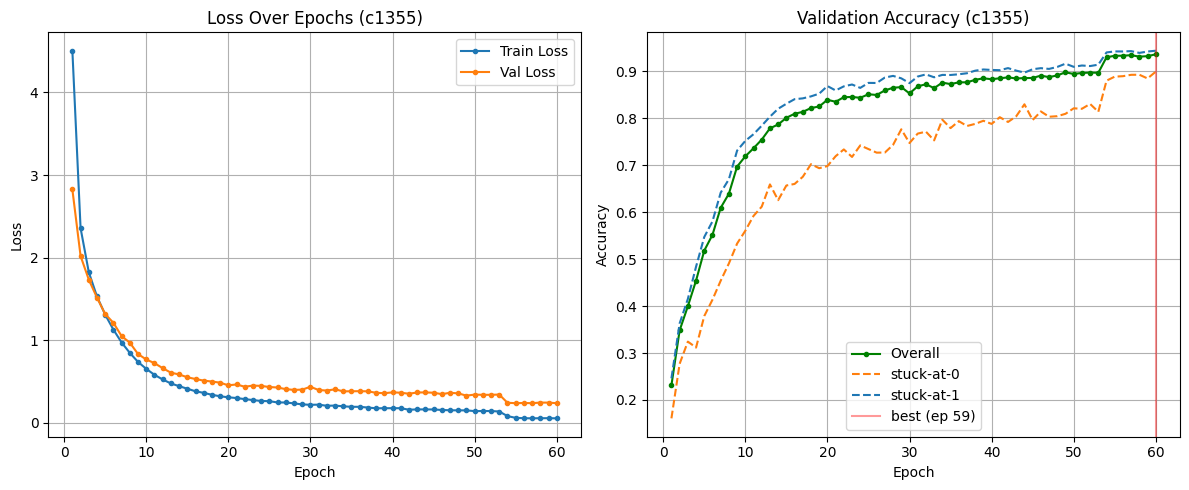

Best overall accuracy: 0.9366 at epoch 59

Your prior LSTM (c1355) overall = 0.6963 | this run best = 0.9366 (delta +24.03 pts)


In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(epochs, val_losses,   label='Val Loss',   marker='o', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Over Epochs (c1355)'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Overall', color='green', marker='o', markersize=3)
plt.plot(epochs, val_sa0_accs,   label='stuck-at-0', color='tab:orange', linestyle='--', markersize=3)
plt.plot(epochs, val_sa1_accs,   label='stuck-at-1', color='tab:blue',   linestyle='--', markersize=3)
plt.axvline(best_epoch + 1, color='red', alpha=0.4, label=f'best (ep {best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation Accuracy (c1355)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print(f"Best overall accuracy: {best_acc:.4f} at epoch {best_epoch}")
print(f"\nYour prior LSTM (c1355) overall = 0.6963 | this run best = {best_acc:.4f} "
      f"(delta {(best_acc-0.6963)*100:+.2f} pts)")


## Tuning for higher accuracy

All knobs are in the config cell.

* **`MAX_SAMPLES` is the biggest lever for this circuit (1574 classes).** The default keeps training to a few minutes; if your run is still improving at the last epoch or samples/class is low, raise it (or set `None` for the full file) and expect a real accuracy bump \u2014 at the cost of longer epochs.
* **`EPOCHS`** \u2014 with best-checkpoint, over-training is safe; if the accuracy curve is still rising, add epochs.
* **`HIDDEN_SIZE`** \u2014 more classes need more capacity; 256\u2192384 can help the 5k-7k-class circuits if VRAM allows.
* **`BITS_PER_STEP`** \u2014 raising it shortens the sequence (faster, sometimes more stable); lowering toward 1 gives the model finer-grained bit positions (slower). 1 is a good balance here.

**Why accuracy differs across circuits:** every circuit here has a ~99-100% information ceiling, so the model is not data-limited \u2014 it is *class-count*-limited. A 1574-way classifier is intrinsically harder than a 1.5k-way one, so report each circuit's number in the context of its class count rather than expecting a single uniform accuracy.

**For the paper:** the cleanest comparison is GNN vs. this LSTM on the *same* circuit and the *same* `MAX_SAMPLES`, since both then see identical data.